# Analyse Solardaten

Susi Sorglos

## Forschungsfragen

1. In welchem Monat wurde bisher am meisten Strom produziert? 

**Ein eigene** Forschungsfrage lautet die Minimalanforderung! 4-gewinnt!

## Daten einlesen

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('KSZO-solar-data.csv', sep=",")

In [3]:
df.tail()

,time_utc,time_local,consumption,production,battery_charging,battery_discharging,battery_currentPower,battery_activeDevice,smart_meter_currentPower,smart_meter_activeDevice,inverter_WR_MS1_currentPower,inverter_WR_MS1_activeDevice,inverter_SolarEdge_SE_currentPower,inverter_SolarEdge_SE_activeDevice,inverter_WR_MS2_currentPower,inverter_WR_MS2_activeDevice
77163,2026-03-11T11:30:00,2026-03-11T12:30:00,66987,90984,0,0,-10019.00,1.0,-23996.33,1.0,30900.67,1.0,30900.67,1.0,29182.33,1.0
77164,2026-03-11T11:45:00,2026-03-11T12:45:00,62299,87617,0,0,-10026.00,1.0,-25317.33,1.0,29737.33,1.0,29737.33,1.0,28143.00,1.0
77165,2026-03-11T12:00:00,2026-03-11T13:00:00,60324,136516,0,0,-10012.33,1.0,-76339.00,1.0,46576.00,1.0,46576.00,1.0,43364.33,1.0
77166,2026-03-11T12:15:00,2026-03-11T13:15:00,65548,106002,0,0,-10008.00,1.0,-41052.00,1.0,36034.67,1.0,36034.67,1.0,33933.00,1.0
77167,2026-03-11T12:30:00,2026-03-11T13:30:00,61946,87009,0,0,-10006.00,1.0,-25062.00,1.0,29572.50,1.0,29572.50,1.0,27864.00,1.0


In [4]:
df.describe()

,consumption,production,battery_charging,battery_discharging,battery_currentPower,battery_activeDevice,smart_meter_currentPower,smart_meter_activeDevice,inverter_WR_MS1_currentPower,inverter_WR_MS1_activeDevice,inverter_SolarEdge_SE_currentPower,inverter_SolarEdge_SE_activeDevice,inverter_WR_MS2_currentPower,inverter_WR_MS2_activeDevice
count,77168.000000,77168.000000,77168.0,77168.0,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000,75459.000000
mean,26225.697323,29743.150853,0.0,0.0,397.163727,0.773453,-2097.168527,0.783790,10526.983801,0.445951,9775.468057,0.395579,10116.253182,0.446203
std,21170.904711,57284.240071,0.0,0.0,3277.503354,0.418600,42069.929279,0.411662,19685.964894,0.497073,19514.176152,0.488978,19206.374419,0.497101
min,0.000000,0.000000,0.0,0.0,-10057.670000,0.000000,-245751.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9524.000000,0.000000,0.0,0.0,-52.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16702.000000,0.000000,0.0,0.0,-52.000000,1.000000,8467.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42226.000000,28662.250000,0.0,0.0,0.000000,1.000000,10705.165000,1.000000,10810.625000,1.000000,8179.395000,1.000000,9936.325000,1.000000
max,109785.000000,268980.000000,0.0,0.0,19793.000000,1.000000,84918.810000,1.000000,89854.560000,1.000000,89972.220000,1.000000,89283.110000,1.000000


## Daten vorverarbeiten

Wir benötigen nur die Spalten `time_local` und `production` und müssen zwei neue Spalten berechnen, nämlich das Jahr und den Monat, in dem ein jeder Datenpunkt liegt.

In [5]:
df = df.loc[:,['time_local', 'production']]

In [6]:
df['time_local'] = pd.to_datetime(df['time_local'])

In [7]:
df['year'] = df['time_local'].dt.year
df['month'] = df['time_local'].dt.month

In [8]:
df.loc[:,'production_Wh'] = df['production'] / 4
df = df.drop(columns=['production'])

Damit wir mit `sum()` die Viertelstundenwerte der Leistung `P` aggregieren können und `Wh` als Einheit erhalten, müssen wir die Leistung jeweils durch 4 dividieren. Warum?

$$W = P \cdot t$$

d.h. um die elektrische Arbeit (`W`) in der Einheit `Wh` aus Leistungsmessungen über $t = \frac{1}{4}h$ zu berechnen, müssen wir die Leistung $P$, die für 15min geleistet wird, mit $\frac{1}{4}$ multiplizieren bzw. durch $4$ dividieren, um auf `Wh` als Einheit zu kommen.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77168 entries, 0 to 77167
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time_local     77168 non-null  datetime64[ns]
 1   year           77168 non-null  int32         
 2   month          77168 non-null  int32         
 3   production_Wh  77168 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 1.8 MB


In [10]:
df.tail()

,time_local,year,month,production_Wh
77163,2026-03-11 12:30:00,2026,3,22746.00
77164,2026-03-11 12:45:00,2026,3,21904.25
77165,2026-03-11 13:00:00,2026,3,34129.00
77166,2026-03-11 13:15:00,2026,3,26500.50
77167,2026-03-11 13:30:00,2026,3,21752.25


<Axes: xlabel='time_local'>

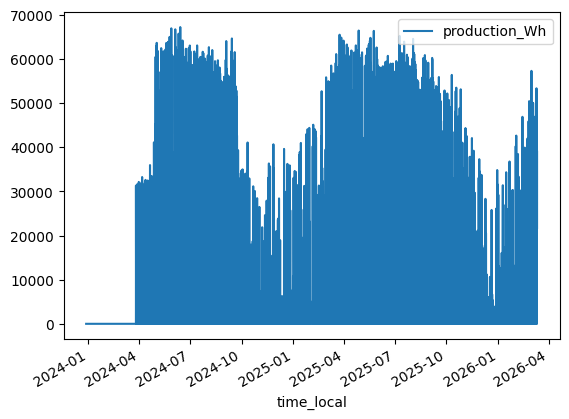

In [11]:
df.plot(x='time_local', y=['production_Wh'])

Die Daten vor April 2024 sehen falsch aus. Wir entfernen diese.

In [12]:
f = df['time_local'] >= pd.to_datetime('2024-04-01')
df = df[f]

<Axes: xlabel='time_local'>

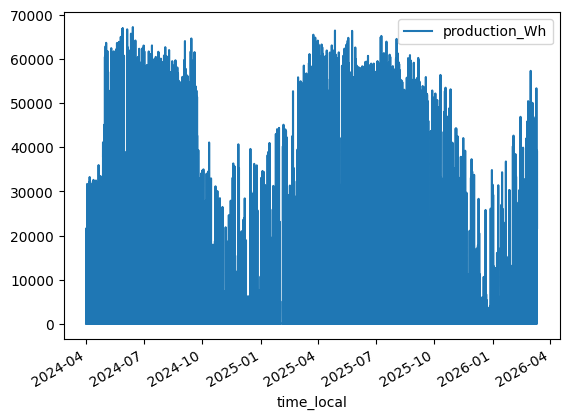

In [13]:
df.plot(x='time_local', y=['production_Wh'])

## Daten analysieren

<Axes: xlabel='year,month'>

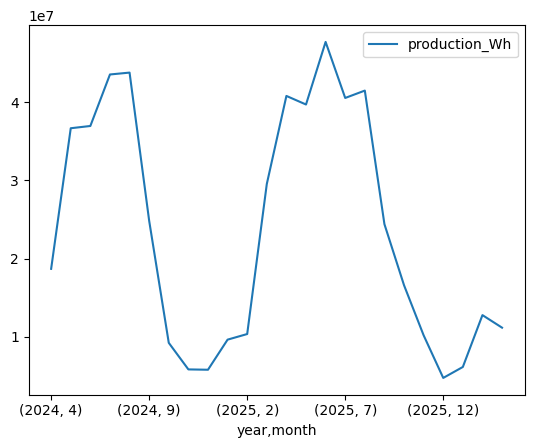

In [14]:
df.pivot_table(index=['year', 'month'], 
               values=['production_Wh'], 
               aggfunc='sum').plot()

### In welchem Monat wurde bisher am meisten Strom produziert?

#### Juni 2025: 47.7 MWh

In [15]:
df.pivot_table(index=['year', 'month'], 
               values=['production_Wh'], 
               aggfunc='sum')\
  .sort_values('production_Wh', ascending=False)\
  .head(5)

production_Wh
year month               
2025 6         47718669.5
2024 8         43795359.0
     7         43554884.5
2025 8         41494156.5
     4         40811463.0

## Ende